In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [8]:
data = pd.read_csv("household_power_consumption.txt", sep=";")

/var/folders/w1/684s5ms515348ms3yt5nj7_40000gn/T/ipykernel_75380/3483890989.py:1: DtypeWarning: Columns (0: Global_active_power, 1: Global_reactive_power, 2: Voltage, 3: Global_intensity, 4: Sub_metering_1, 5: Sub_metering_2) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("household_power_consumption.txt", sep=";")


In [9]:
df = data.copy()

In [10]:
df['datetime'] = pd.to_datetime(df['Date'] + " " + df['Time'], dayfirst=True)
df = df.sort_values('datetime')
df = df.set_index('datetime')

In [11]:
df["Global_active_power"] = pd.to_numeric(df["Global_active_power"], errors="coerce")

Text(0.5, 1.0, 'Distribution of Global Active Power')

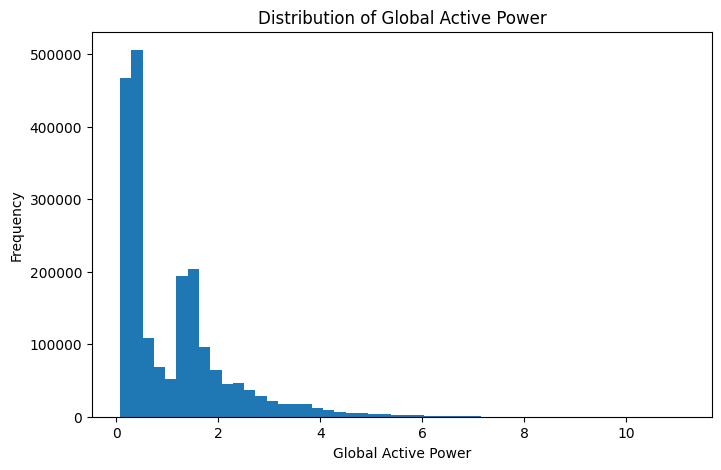

In [12]:
# We are trying to predict Global_active_power

plt.figure(figsize=(8, 5))
plt.hist(df["Global_active_power"], bins=50)
plt.xlabel("Global Active Power")
plt.ylabel("Frequency")
plt.title("Distribution of Global Active Power")


Text(0.5, 1.0, 'Global Active Power Over Time')

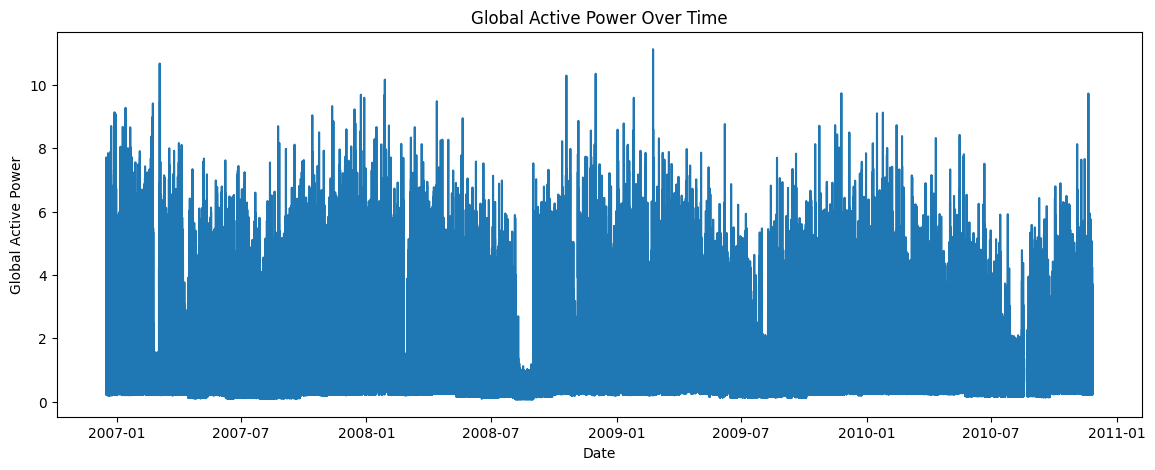

In [13]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Global_active_power"])
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.title("Global Active Power Over Time")


Text(0.5, 1.0, 'Daily Average Power Usage')

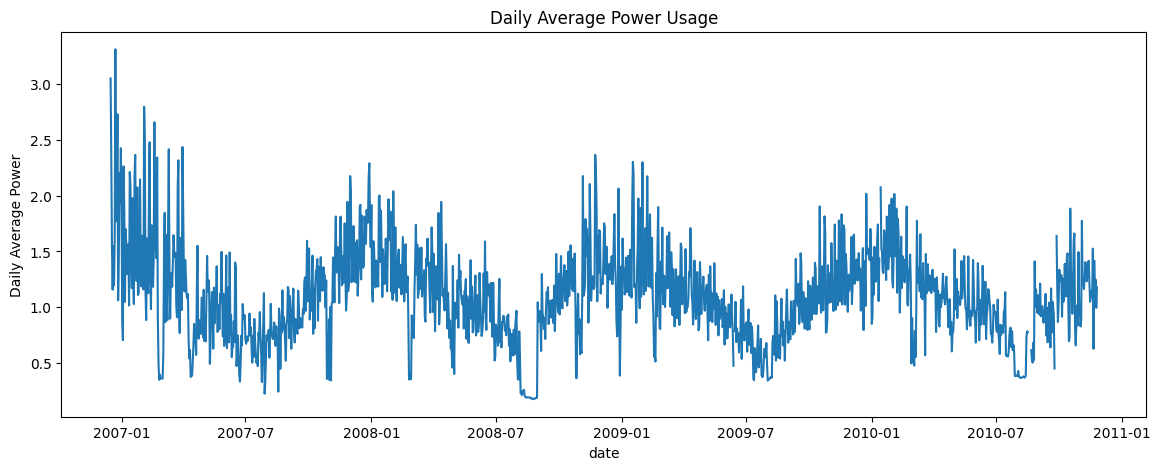

In [14]:
daily_power = df["Global_active_power"].resample("D").mean()

plt.figure(figsize=(14, 5))
plt.plot(daily_power)
plt.xlabel("date")
plt.ylabel("Daily Average Power")
plt.title("Daily Average Power Usage")



Text(0.5, 1.0, 'Weekly Average Power Usage')

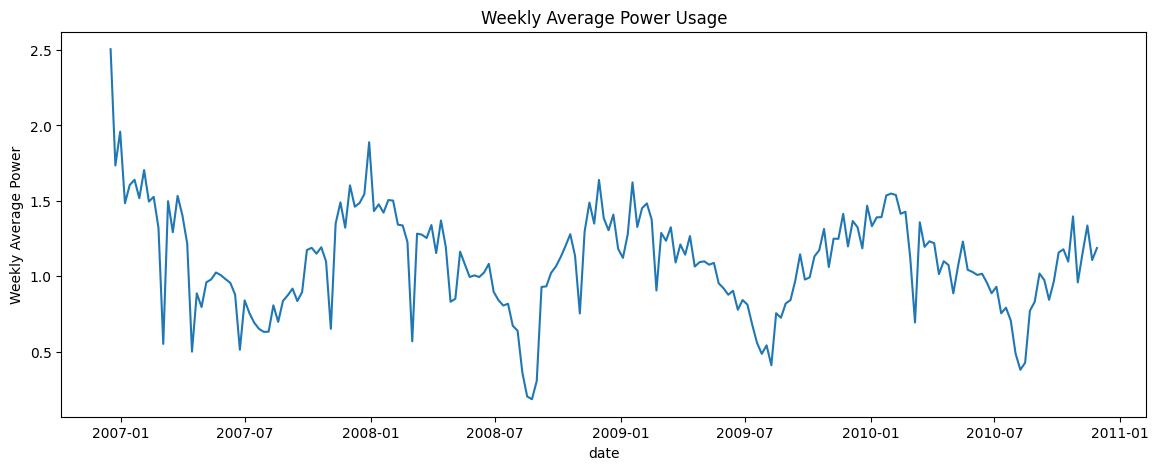

In [15]:
weekly_power = df["Global_active_power"].resample("W").mean()

plt.figure(figsize=(14, 5))
plt.plot(weekly_power)
plt.xlabel("date")
plt.ylabel("Weekly Average Power")
plt.title("Weekly Average Power Usage")

Text(0.5, 1.0, 'Monthly Average Power Usage')

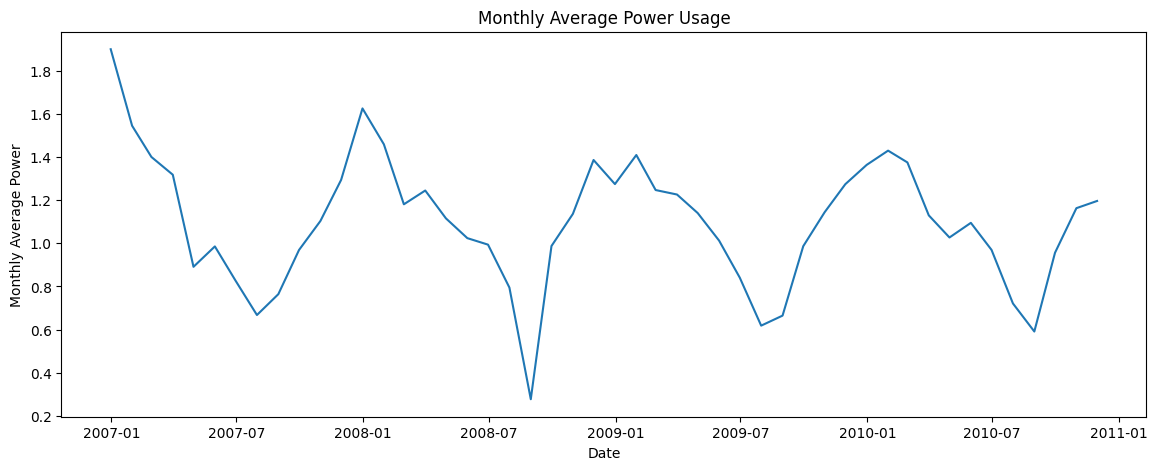

In [16]:
monthly_power = df["Global_active_power"].resample("ME").mean()

plt.figure(figsize=(14, 5))
plt.plot(monthly_power)
plt.xlabel("Date")
plt.ylabel("Monthly Average Power")
plt.title("Monthly Average Power Usage")


# based on the graph below, the average monthly power consumption is higher during winters and lower during summers

Text(0.5, 1.0, 'Average Power Usage by Hour')

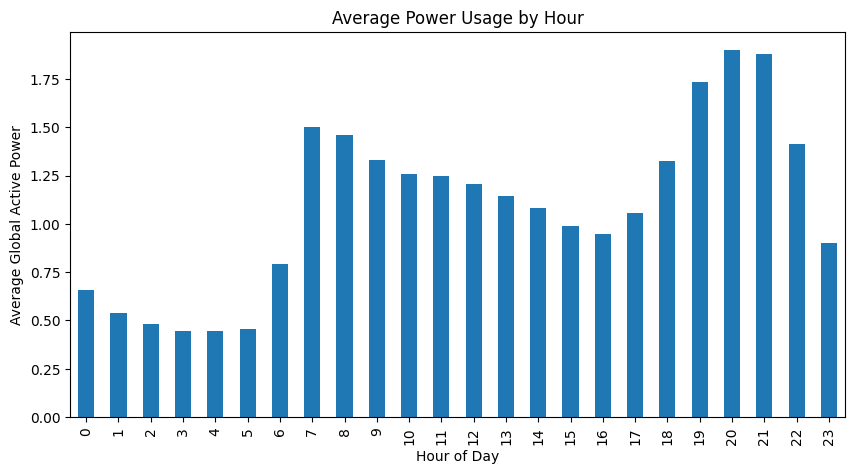

In [17]:
# analyzing average energy consumption by the hour

df['hour'] = df.index.hour

hourly_avg = df.groupby("hour")['Global_active_power'].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot(kind='bar')
plt.xlabel("Hour of Day")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Hour")

Text(0.5, 1.0, 'Average Power Usage by Day of Week')

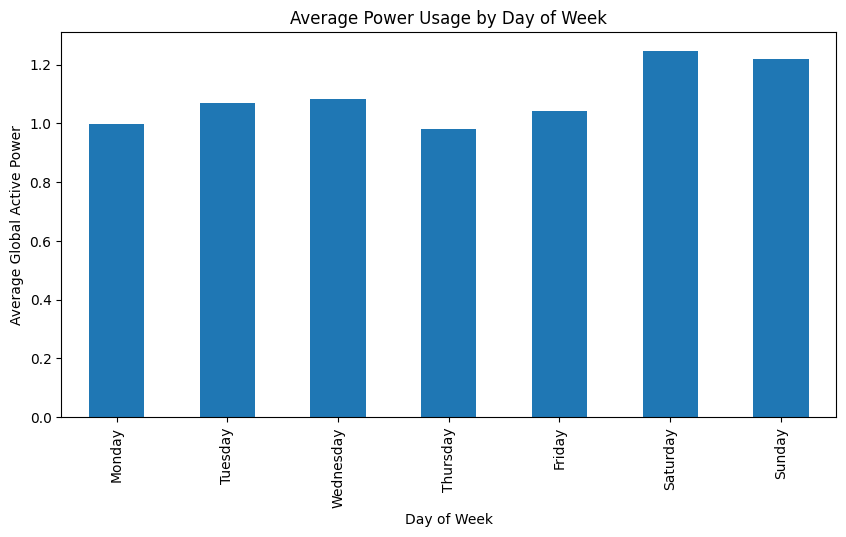

In [18]:
# day of the week pattern  - slightly higher on saturdays and sundays

df['day'] = df.index.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

day_of_week_avg = df.groupby('day')["Global_active_power"].mean().reindex(order)

plt.figure(figsize=(10,5))
day_of_week_avg.plot(kind='bar')
plt.xlabel("Day of Week")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Day of Week")



Text(0.5, 1.0, 'Average Power Usage by Month')

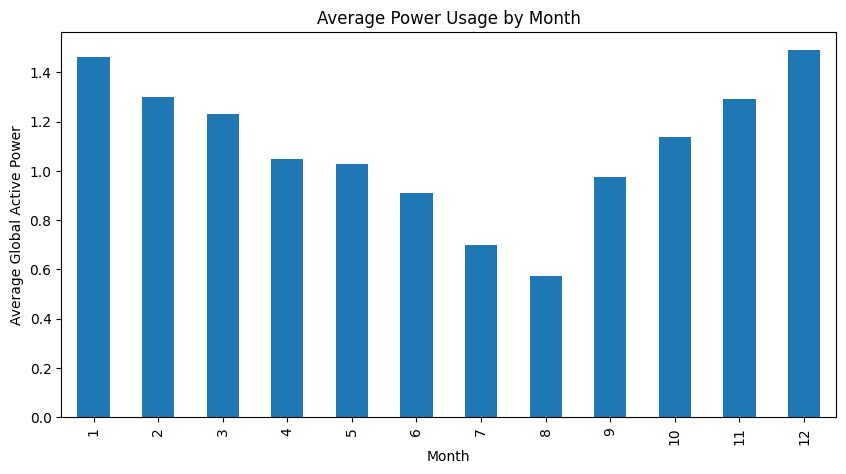

In [19]:
df['month'] = df.index.month

monthly_pattern = df.groupby('month')['Global_active_power'].mean()

plt.figure(figsize=(10,5))
monthly_pattern.plot(kind="bar")
plt.xlabel("Month")
plt.ylabel("Average Global Active Power")
plt.title("Average Power Usage by Month")

Text(0.5, 1.0, 'Total Energy by Sub-Metering Area')

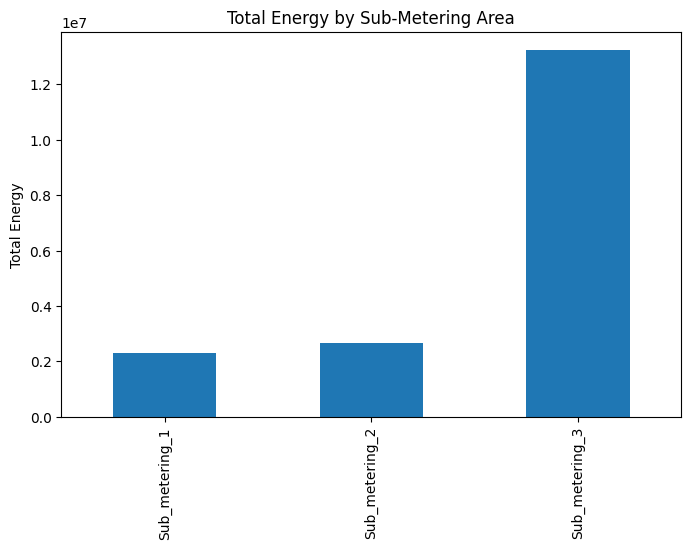

In [20]:
# sub meter 3 uses the most energy and aub meters 1 and 2 use about the same energy

sub_meter_cols = ['Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df['Sub_metering_1'] = pd.to_numeric(df['Sub_metering_1'], errors="coerce")
df['Sub_metering_2'] = pd.to_numeric(df['Sub_metering_2'], errors="coerce")
df['Sub_metering_3'] = pd.to_numeric(df['Sub_metering_3'], errors="coerce")

df[sub_meter_cols].sum().plot(kind='bar', figsize=(8,5))
plt.ylabel("Total Energy")
plt.title("Total Energy by Sub-Metering Area")

In [21]:
# converting to watts per minute
df["global_active_energy"] = df["Global_active_power"] * 1000 / 60
df['total_metered'] = (df['Sub_metering_1'] + df['Sub_metering_2'] + df["Sub_metering_3"])

df["unmetered_energy"] = df["global_active_energy"] - df["total_metered"]

Text(0.5, 1.0, 'Metered vs Unmetered Energy Over Time')

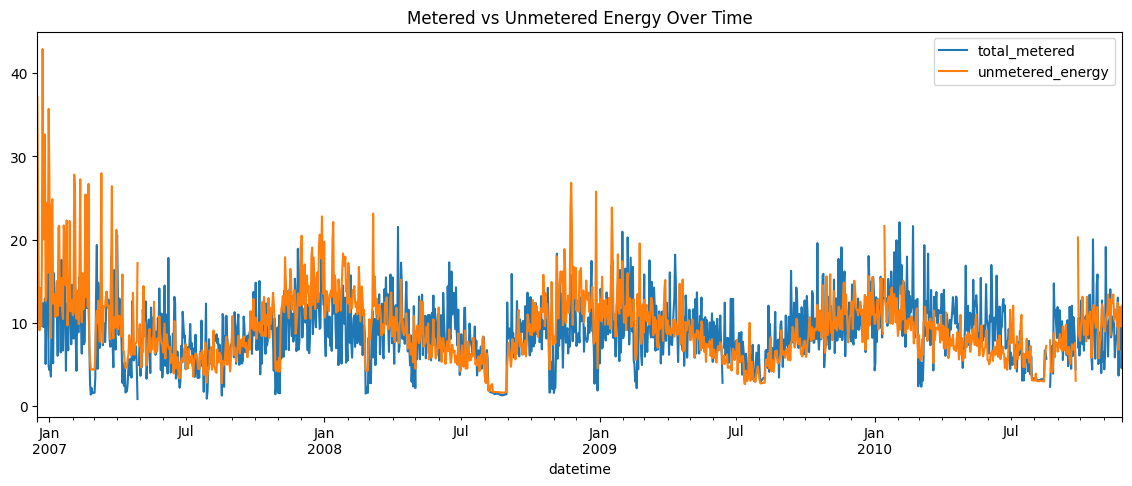

In [22]:
df[["total_metered", "unmetered_energy"]].resample("D").mean().plot(figsize=(14, 5))
plt.title("Metered vs Unmetered Energy Over Time")


Text(0.5, 1.0, 'Correlation Matrix of Power Consumption Features')

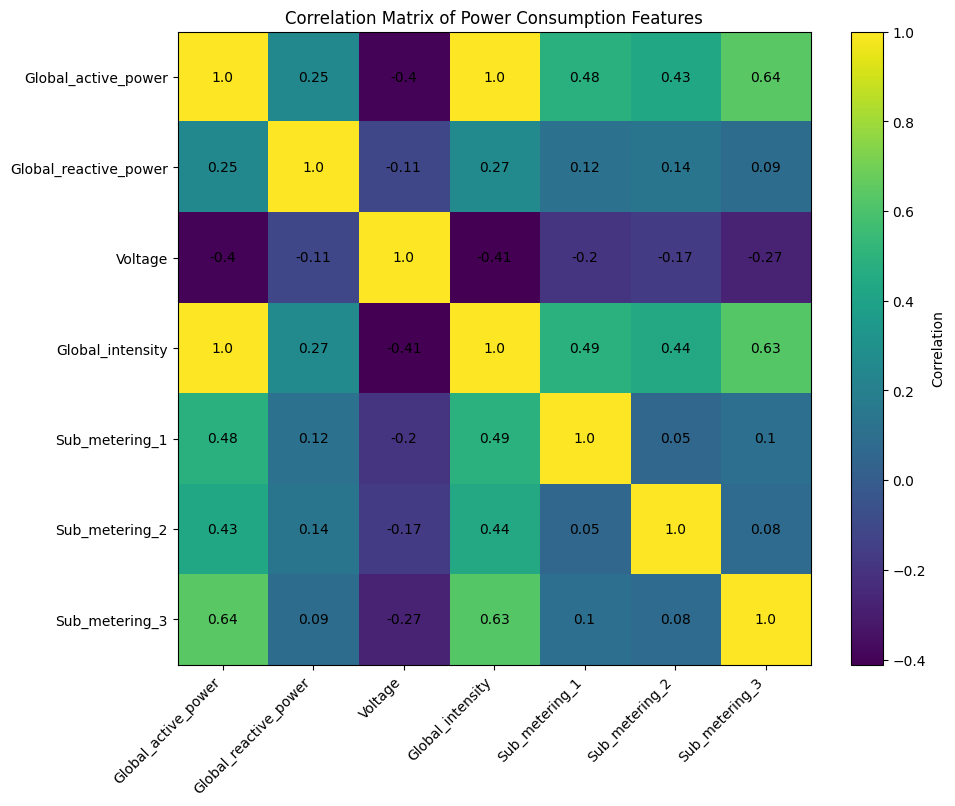

In [23]:
numeric_cols = [
    "Global_active_power",
    "Global_reactive_power",
    "Voltage",
    "Global_intensity",
    "Sub_metering_1",
    "Sub_metering_2",
    "Sub_metering_3"
]

df = df.dropna(subset=numeric_cols)

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

corr = df[numeric_cols].corr()
# corr["Global_active_power"].sort_values(ascending=False)

# Plot correlation heatmap
plt.figure(figsize=(10, 8))
plt.imshow(corr, interpolation="nearest")
plt.colorbar(label="Correlation")

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2), ha="center", va="center")

plt.tight_layout()

plt.title("Correlation Matrix of Power Consumption Features")

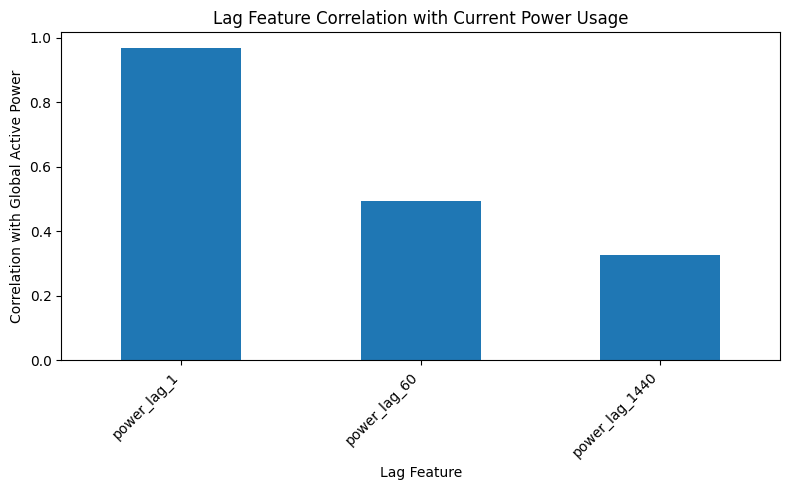

In [24]:
# Lag analysis - indentifying delays in the data

df["power_lag_1"] = df["Global_active_power"].shift(1)
df["power_lag_60"] = df["Global_active_power"].shift(60)
df["power_lag_1440"] = df["Global_active_power"].shift(1440)

df = df.dropna(subset=['power_lag_1', "power_lag_60", "power_lag_1440"])

lag_cols = [
    "Global_active_power",
    "power_lag_1",
    "power_lag_60",
    "power_lag_1440"
]

lag_corr = df[lag_cols].corr()["Global_active_power"].sort_values(ascending=False)

lag_corr_only = lag_corr.drop("Global_active_power")

plt.figure(figsize=(8, 5))
lag_corr_only.plot(kind="bar")

plt.xlabel("Lag Feature")
plt.ylabel("Correlation with Global Active Power")
plt.title("Lag Feature Correlation with Current Power Usage")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

Text(0.5, 1.0, 'Original Power vs Rolling Average')

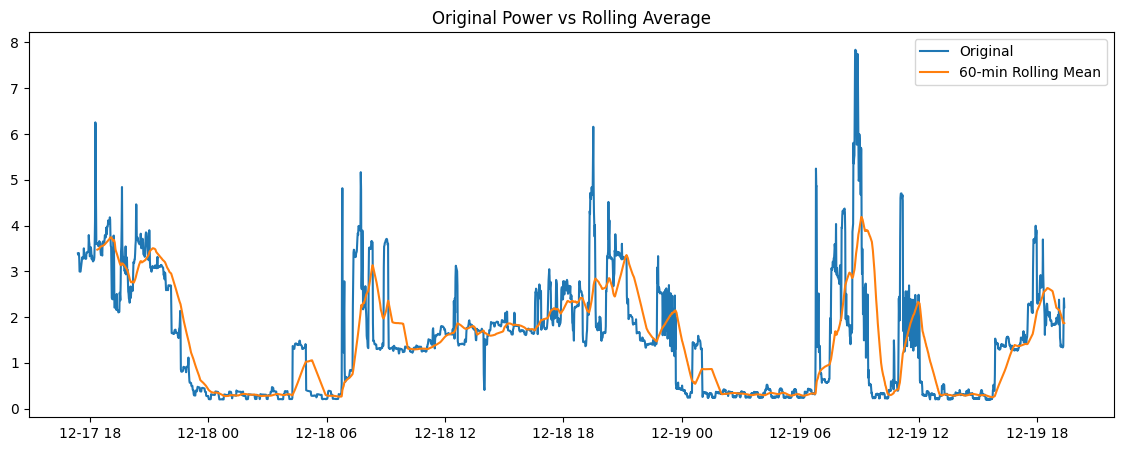

In [28]:
# 60 minutes rolling mean for a small sample

df["rolling_mean_60"] = df["Global_active_power"].rolling(60).mean()
df["rolling_std_60"] = df["Global_active_power"].rolling(60).std()
df["rolling_mean_1440"] = df["Global_active_power"].rolling(1440).mean()

sample = df.iloc[:3000]

plt.figure(figsize=(14, 5))
plt.plot(sample.index, sample["Global_active_power"], label="Original")
plt.plot(sample.index, sample["rolling_mean_60"], label="60-min Rolling Mean")
plt.legend()
plt.title("Original Power vs Rolling Average")

In [53]:
# creating a target_next_hour to predict Global_active_power 1 hour into the future, adding is_weekend column

df["target_next_hour"] = df["Global_active_power"].shift(-60)


In [54]:
df['day_of_week'] = df.index.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6]).astype(int)

In [73]:
df.to_parquet("power_clean.parquet")

In [71]:
df.head()
# df = df.dropna()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,hour,...,unmetered_energy,power_lag_1,power_lag_60,power_lag_1440,rolling_mean_60,rolling_std_60,rolling_mean_1440,target_next_hour,is_weekend,day_of_week
datetime,,,,,,,,,,,,,,,,,,,,,
2006-12-18 17:23:00,18/12/2006,17:23:00,1.950,0.000,239.13,8.0,0.0,0.0,18.0,17,...,14.500000,2.492,1.696,3.238,2.143667,0.440523,1.619929,2.442,0,0
2006-12-18 17:24:00,18/12/2006,17:24:00,1.956,0.000,239.57,8.0,0.0,0.0,18.0,17,...,14.600000,1.950,1.648,3.390,2.148800,0.436424,1.618933,2.464,0,0
2006-12-18 17:25:00,18/12/2006,17:25:00,2.068,0.122,239.48,8.6,0.0,0.0,17.0,17,...,17.466667,1.956,1.646,3.360,2.155833,0.431557,1.618036,2.472,0,0
2006-12-18 17:26:00,18/12/2006,17:26:00,2.036,0.108,239.94,8.4,0.0,0.0,18.0,17,...,15.933333,2.068,1.646,3.400,2.162333,0.426657,1.617089,2.292,0,0
2006-12-18 17:27:00,18/12/2006,17:27:00,1.876,0.094,240.22,7.8,0.0,0.0,17.0,17,...,14.266667,2.036,1.646,3.396,2.166167,0.422957,1.616033,1.880,0,0
